*Functions used:* `pd.read_csv()`, `display()`, `Image()`, `describe()`, `plt.hist()`, `plt.show()`, `sns.heatmap()`, `sm.add_constant()`, `sm.OLS()`, `variance_inflation_factor()`, `compute_vif()`, `train_test_split()`, `r2_score()`, `xgb.XGBRegressor()`, `shap.TreeExplainer()`, `shap.plots.beeswarm()`

# Research Workflow & Exploratory Data Analysis

Presents the end-to-end research design and examines the distribution of the outcome variable.

## Load Processed Data

In [1]:
import numpy as np
import pandas as pd
from IPython.display import Image, display

analysis_df = pd.read_csv('processed_data.csv')

OUTCOME  = 'crime_rate_per_100000'
UNEM     = 'Unemployment_rate_2023'
POV      = 'PCTPOVALL_2023'
CONTROLS = ['MEDHHINC_2023',
    "Percent of adults who are not high school graduates, 2019-23",
    "Percent of adults with a bachelor's degree or higher, 2019-23",]
FEATURES = [c for c in [UNEM, POV] + CONTROLS if c in analysis_df.columns]

print(f"Loaded {len(analysis_df):,} counties | Features: {FEATURES}")

Loaded 3,123 counties | Features: ['Unemployment_rate_2023', 'PCTPOVALL_2023', 'MEDHHINC_2023', 'Percent of adults who are not high school graduates, 2019-23', "Percent of adults with a bachelor's degree or higher, 2019-23"]


## 1. Research Workflow

**Figure 2.** End-to-end research workflow: from raw data sources through model estimation to threshold detection.

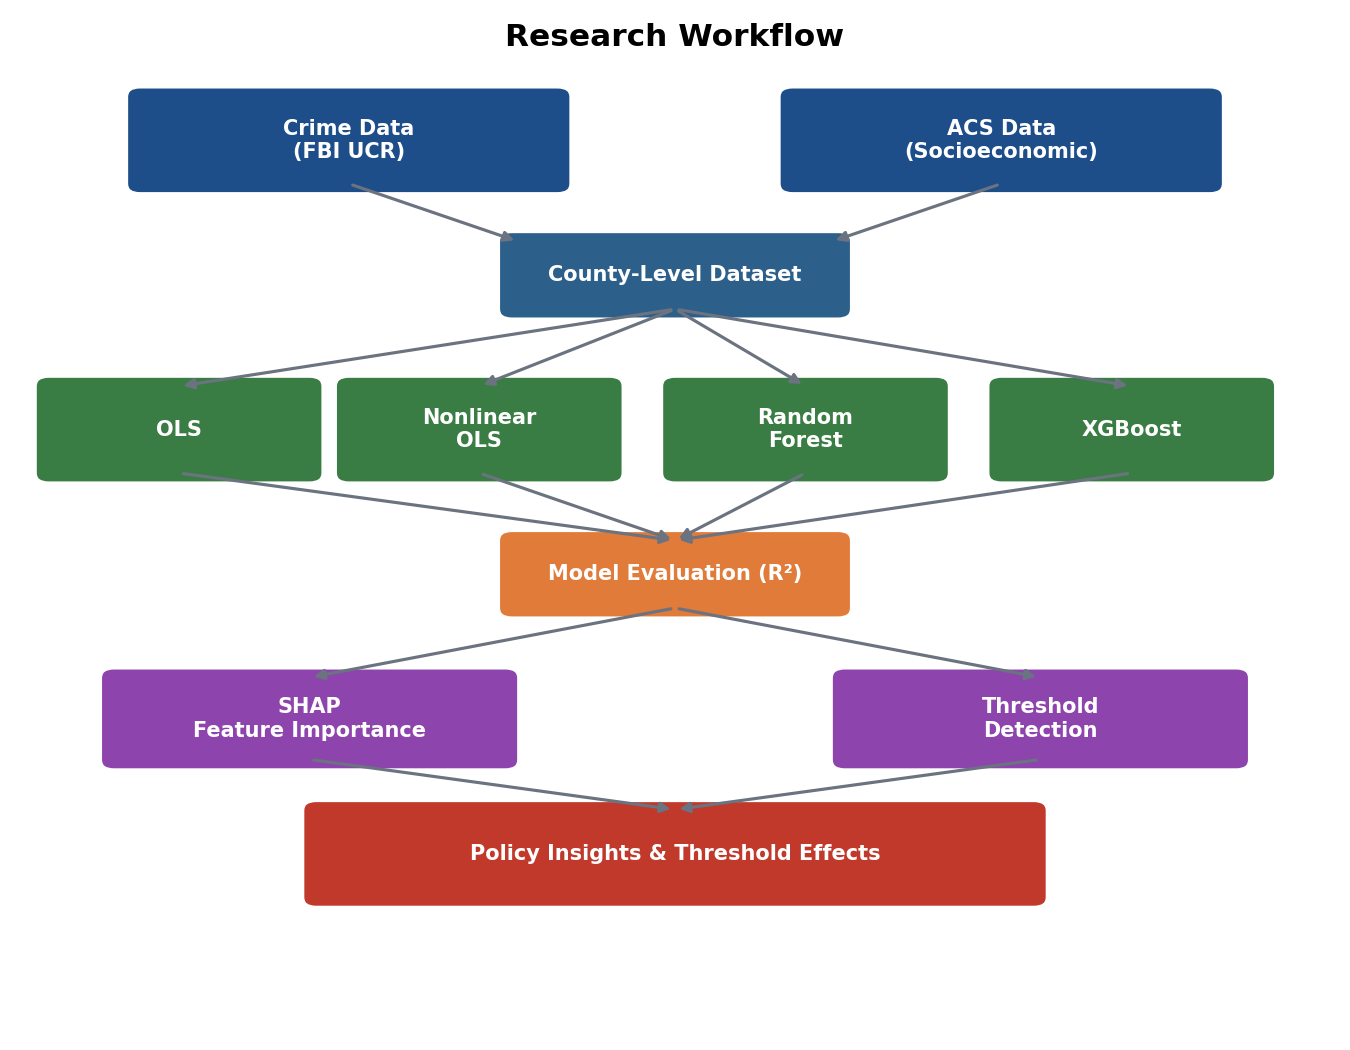

In [2]:
display(Image('figures/research_workflow.png', width=760))

## 2. Exploratory Data Analysis

Summary statistics and distribution of the outcome variable across U.S. counties.

In [3]:
print(analysis_df[[OUTCOME, UNEM, POV]].describe().round(2))

       crime_rate_per_100000  Unemployment_rate_2023  PCTPOVALL_2023
count                3123.00                 3123.00         3123.00
mean                  235.48                    3.58           14.50
std                   200.66                    1.20            5.53
min                     0.00                    0.30            3.30
25%                    95.08                    2.80           10.60
50%                   186.25                    3.40           13.60
75%                   321.82                    4.10           17.40
max                  1792.00                   17.30           49.60


**Figure 1.** Distribution of violent crime rates across U.S. counties. The distribution is right-skewed — most counties fall below 400 per 100,000, with a long right tail of high-crime counties.

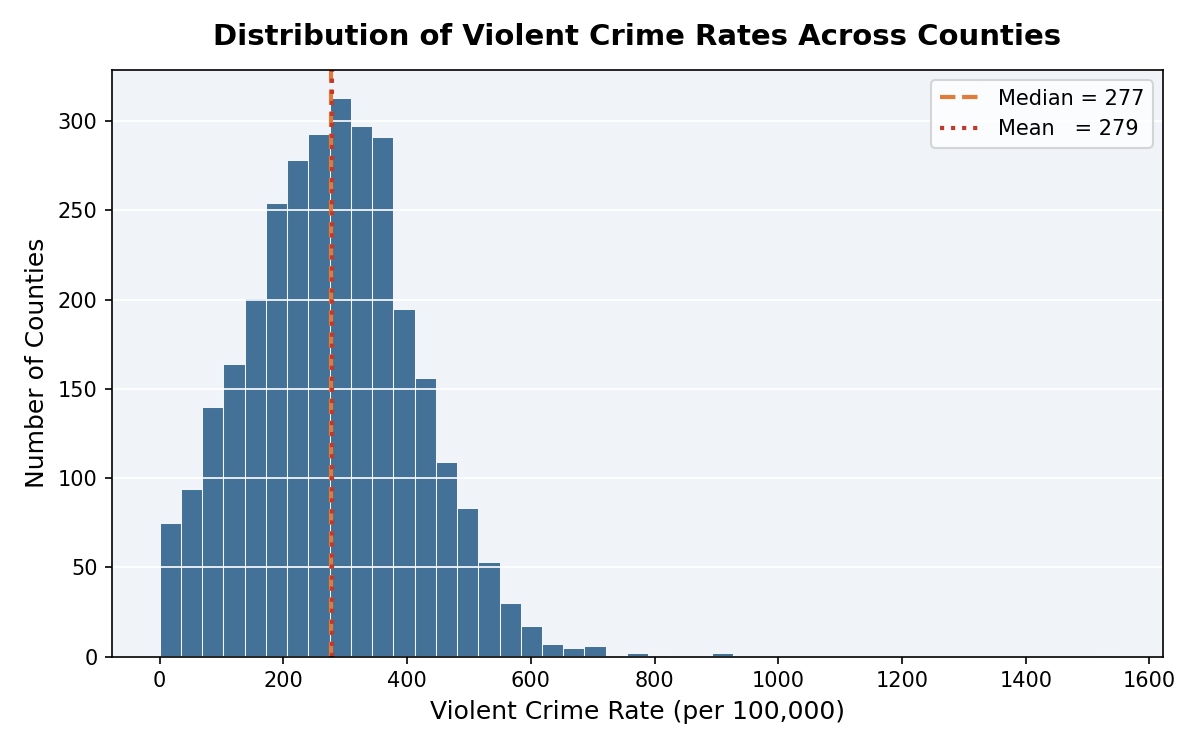

In [4]:
display(Image('figures/crime_hist.png', width=700))